<a href="https://colab.research.google.com/github/vedanshu-1234/Data_Science_Assignment/blob/main/International_T_20_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("International_T20_Data.csv")

In [ ]:
df.head(5)

,innings,meta.data_version,meta.created,meta.revision,info.dates,info.gender,info.match_type,info.outcome.by.wickets,info.outcome.winner,info.overs,...,info.outcome.by.runs,info.match_type_number,info.neutral_venue,info.outcome.method,info.outcome.result,info.outcome.eliminator,info.supersubs.New Zealand,info.supersubs.South Africa,info.bowl_out,info.outcome.bowl_out
0,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-18,2,"[datetime.date(2017, 2, 17)]",male,T20,5.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-19,2,"[datetime.date(2017, 2, 19)]",male,T20,2.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-23,1,"[datetime.date(2017, 2, 22)]",male,T20,NaN,Australia,20,...,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[{'1st innings': {'team': 'Hong Kong', 'delive...",0.9,2016-09-12,1,"[datetime.date(2016, 9, 5)]",male,T20,NaN,Hong Kong,20,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[{'1st innings': {'team': 'Zimbabwe', 'deliver...",0.9,2016-06-19,1,"[datetime.date(2016, 6, 18)]",male,T20,NaN,Zimbabwe,20,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Rename all the column names to their appropriate names, for example meta.created should be renamed as created_date

In [ ]:
df = df.rename(columns={
    'meta.data_version':'data_version',
    'meta.created':'created_date',
    'meta.revision':'revision',
    'info.dates':'date',
    'info.gender':'gender',
    'info.match_type':'match_type',
    'info.outcome.by.wickets':'outcome_by_wickets',
    'info.outcome.winner':'winner',
    'info.overs':'overs',
    'info.player_of_match':'player_of_match',
    'info.teams':'teams',
    'info.toss.decision':'toss_decision',
    'info.toss.winner':'toss_winner',
    'info.umpires':'umpires',
    'info.venue':'venue',
    'info.city':'city',
    'info.outcome.by.runs':'outcome_by_runs',
    'info.match_type_number':'match_type_number',
    'info.neutral_venue':'neutral_venue',
    'info.outcome.method':'method',
    'info.outcome.result':'result',
    'info.outcome.eliminator':'eliminator',
    'info.supersubs.New Zealand':'supersubs_New Zealand',
    'info.supersubs.South Africa':'supersubs_South Africa',
    'info.bowl_out':'bowl_out',
    'info.outcome.bowl_out':'bowl_out'
})

In [ ]:
df.head(5)

,innings,data_version,created_date,revision,date,gender,match_type,outcome_by_wickets,winner,overs,...,outcome_by_runs,match_type_number,neutral_venue,method,result,eliminator,supersubs_New Zealand,supersubs_South Africa,bowl_out,bowl_out
0,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-18,2,"[datetime.date(2017, 2, 17)]",male,T20,5.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-19,2,"[datetime.date(2017, 2, 19)]",male,T20,2.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-23,1,"[datetime.date(2017, 2, 22)]",male,T20,NaN,Australia,20,...,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[{'1st innings': {'team': 'Hong Kong', 'delive...",0.9,2016-09-12,1,"[datetime.date(2016, 9, 5)]",male,T20,NaN,Hong Kong,20,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[{'1st innings': {'team': 'Zimbabwe', 'deliver...",0.9,2016-06-19,1,"[datetime.date(2016, 6, 18)]",male,T20,NaN,Zimbabwe,20,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Find out the top three venues which hosted the greatest number of matches.

In [ ]:
top_venues = (df['venue'].value_counts()).head(3)
print("Top 3 venues with the greatest number of matches:")
print(top_venues)

Top 3 venues with the greatest number of matches:
venue
Dubai International Cricket Stadium    62
Sheikh Zayed Stadium                   41
Shere Bangla National Stadium          39
Name: count, dtype: int64


## 3. Find out the pair of cricket teams who played the most number of T20 matches against each other.

In [ ]:
import ast

df['teams'] = df['teams'].apply(ast.literal_eval)
df['team_pair'] = df['teams'].apply(lambda x: tuple(sorted(x)))
top_pair = (df['team_pair'].value_counts()).head(1)
print("\nPair of Cricket teams who played the most number of matches:")
print(top_pair)


Pair of Cricket teams who played the most number of matches:
team_pair
(Australia, England)    45
Name: count, dtype: int64


## 4. Print the top five teams by their win percentages. Win percentage is defined as the number of matches won divided by the number of matches played and then multiplied by 100.

In [ ]:
matches_played = {}
for teams in df['teams']:
    for t in teams:
        matches_played[t] = matches_played.get(t,0) + 1

matches_played = pd.Series(matches_played)
wins = df['winner'].value_counts()
win_percentage = (wins / matches_played) * 100
top5 = win_percentage.sort_values(ascending=False).head(5)
print("\nTop 5 Teams by Win Percentage:")
print(top5)


Top 5 Teams by Win Percentage:
Belgium        100.000000
Spain           83.333333
Germany         76.470588
Namibia         73.529412
Afghanistan     68.000000
dtype: float64


## 5. Write a function to get the scorecard of each match. This function would take the innings value as argument and return two scorecard dataframes each for one team as shown below. So the first dataframe would contain the top 4 scorers of the team who batted first and the top 4 bowlers of the opponent team. And the second dataframe would contain the top 4 scorers of the team who batted second and the top 4 bowlers of the opponent team.

In [ ]:
import pandas as pd
import ast
df = pd.read_csv("International_T20_Data.csv")
df["innings"] = df["innings"].apply(ast.literal_eval)

def get_scorecard(innings):
    result = []

    for inn in innings:
        deliveries = list(inn.values())[0]["deliveries"]
        bat, bowl = {}, {}

        for ball in deliveries:
            info = list(ball.values())[0]
            bat[info["batsman"]] = bat.get(info["batsman"], 0) + info["runs"]["batsman"]
            b = info["bowler"]
            bowl.setdefault(b, {"runs":0, "wkts":0})
            bowl[b]["runs"] += info["runs"]["total"]
            if "wicket" in info:
                bowl[b]["wkts"] += 1

        bat_df = pd.DataFrame(bat.items(), columns=["Player","Runs"])\
                   .sort_values("Runs", ascending=False).head(4)
        bowl_df = pd.DataFrame(
            [(k,v["wkts"],v["runs"]) for k,v in bowl.items()],
            columns=["Bowler","Wickets","Runs_Conceded"]
        ).sort_values(["Wickets","Runs_Conceded"],
                      ascending=[False,True]).head(4)

        result.append((bat_df, bowl_df))

    return result

In [ ]:
score = get_scorecard(df["innings"].iloc[0])

# First innings
print(score[0][0])
print(score[0][1])

#second innings
print(score[1][0])
print(score[1][1])

      Player  Runs
0   AJ Finch    43
1  M Klinger    38
2    TM Head    31
4  AJ Turner    18
           Bowler  Wickets  Runs_Conceded
0      SL Malinga        2             29
5   DAS Gunaratne        1             11
4  PADLR Sandakan        1             31
2   JRMVB Sanjaya        1             35
            Player  Runs
3    DAS Gunaratne    52
2   EMDY Munaweera    44
0      N Dickwella    30
4  TAM Siriwardana    15
        Bowler  Wickets  Runs_Conceded
5    AJ Turner        2             12
4      A Zampa        2             26
0   PJ Cummins        1             30
2  JP Faulkner        0             29


# **Visualisation using matplotlib and seaborn**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

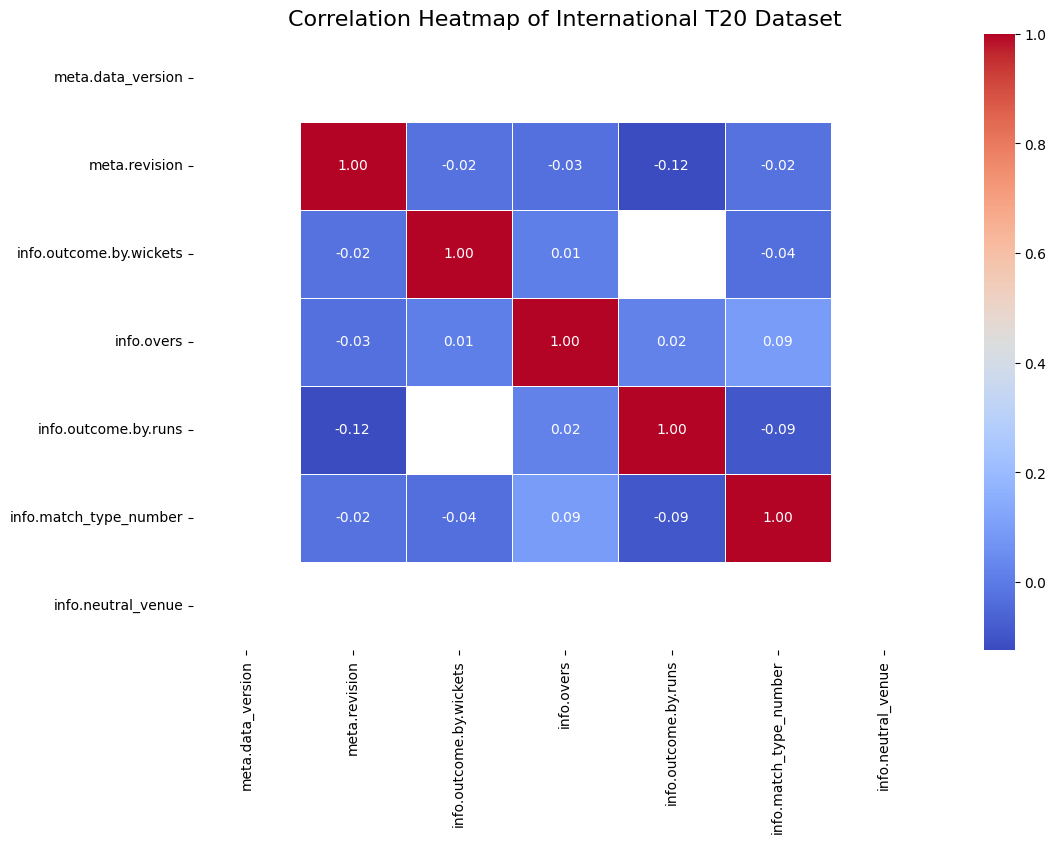

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of International T20 Dataset", fontsize=16)
plt.show()


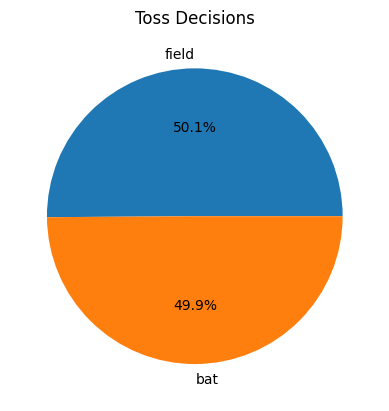

In [ ]:
count_toss_decision = df['toss_decision'].value_counts()
plt.pie(count_toss_decision, labels=count_toss_decision.index, autopct='%1.1f%%')
plt.title('Toss Decisions')
plt.show()

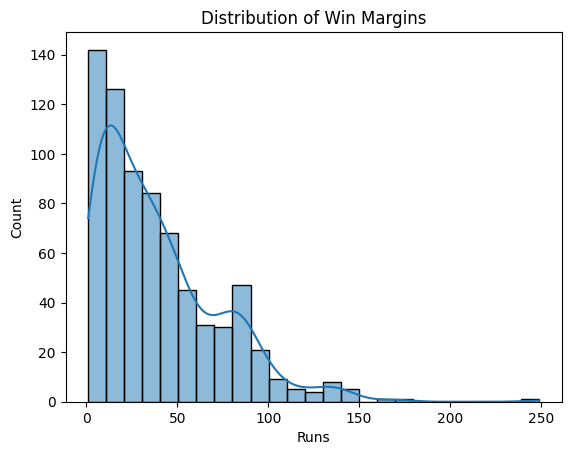

In [ ]:
runs_margin = df['outcome_by_runs'].dropna()
sns.histplot(runs_margin, bins=25, kde=True)
plt.title('Distribution of Win Margins')
plt.xlabel('Runs')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_9747/1126737120.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_winners.values, y=top_winners.index, palette='viridis')


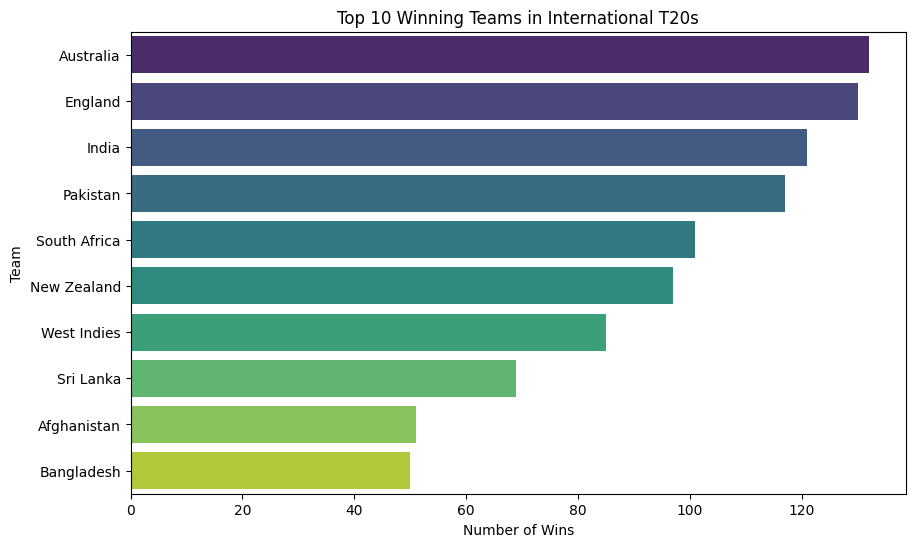

In [ ]:
plt.figure(figsize=(10, 6))
top_winners = df['winner'].value_counts().head(10)
sns.barplot(x=top_winners.values, y=top_winners.index, palette='viridis')
plt.title('Top 10 Winning Teams in International T20s')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.show()

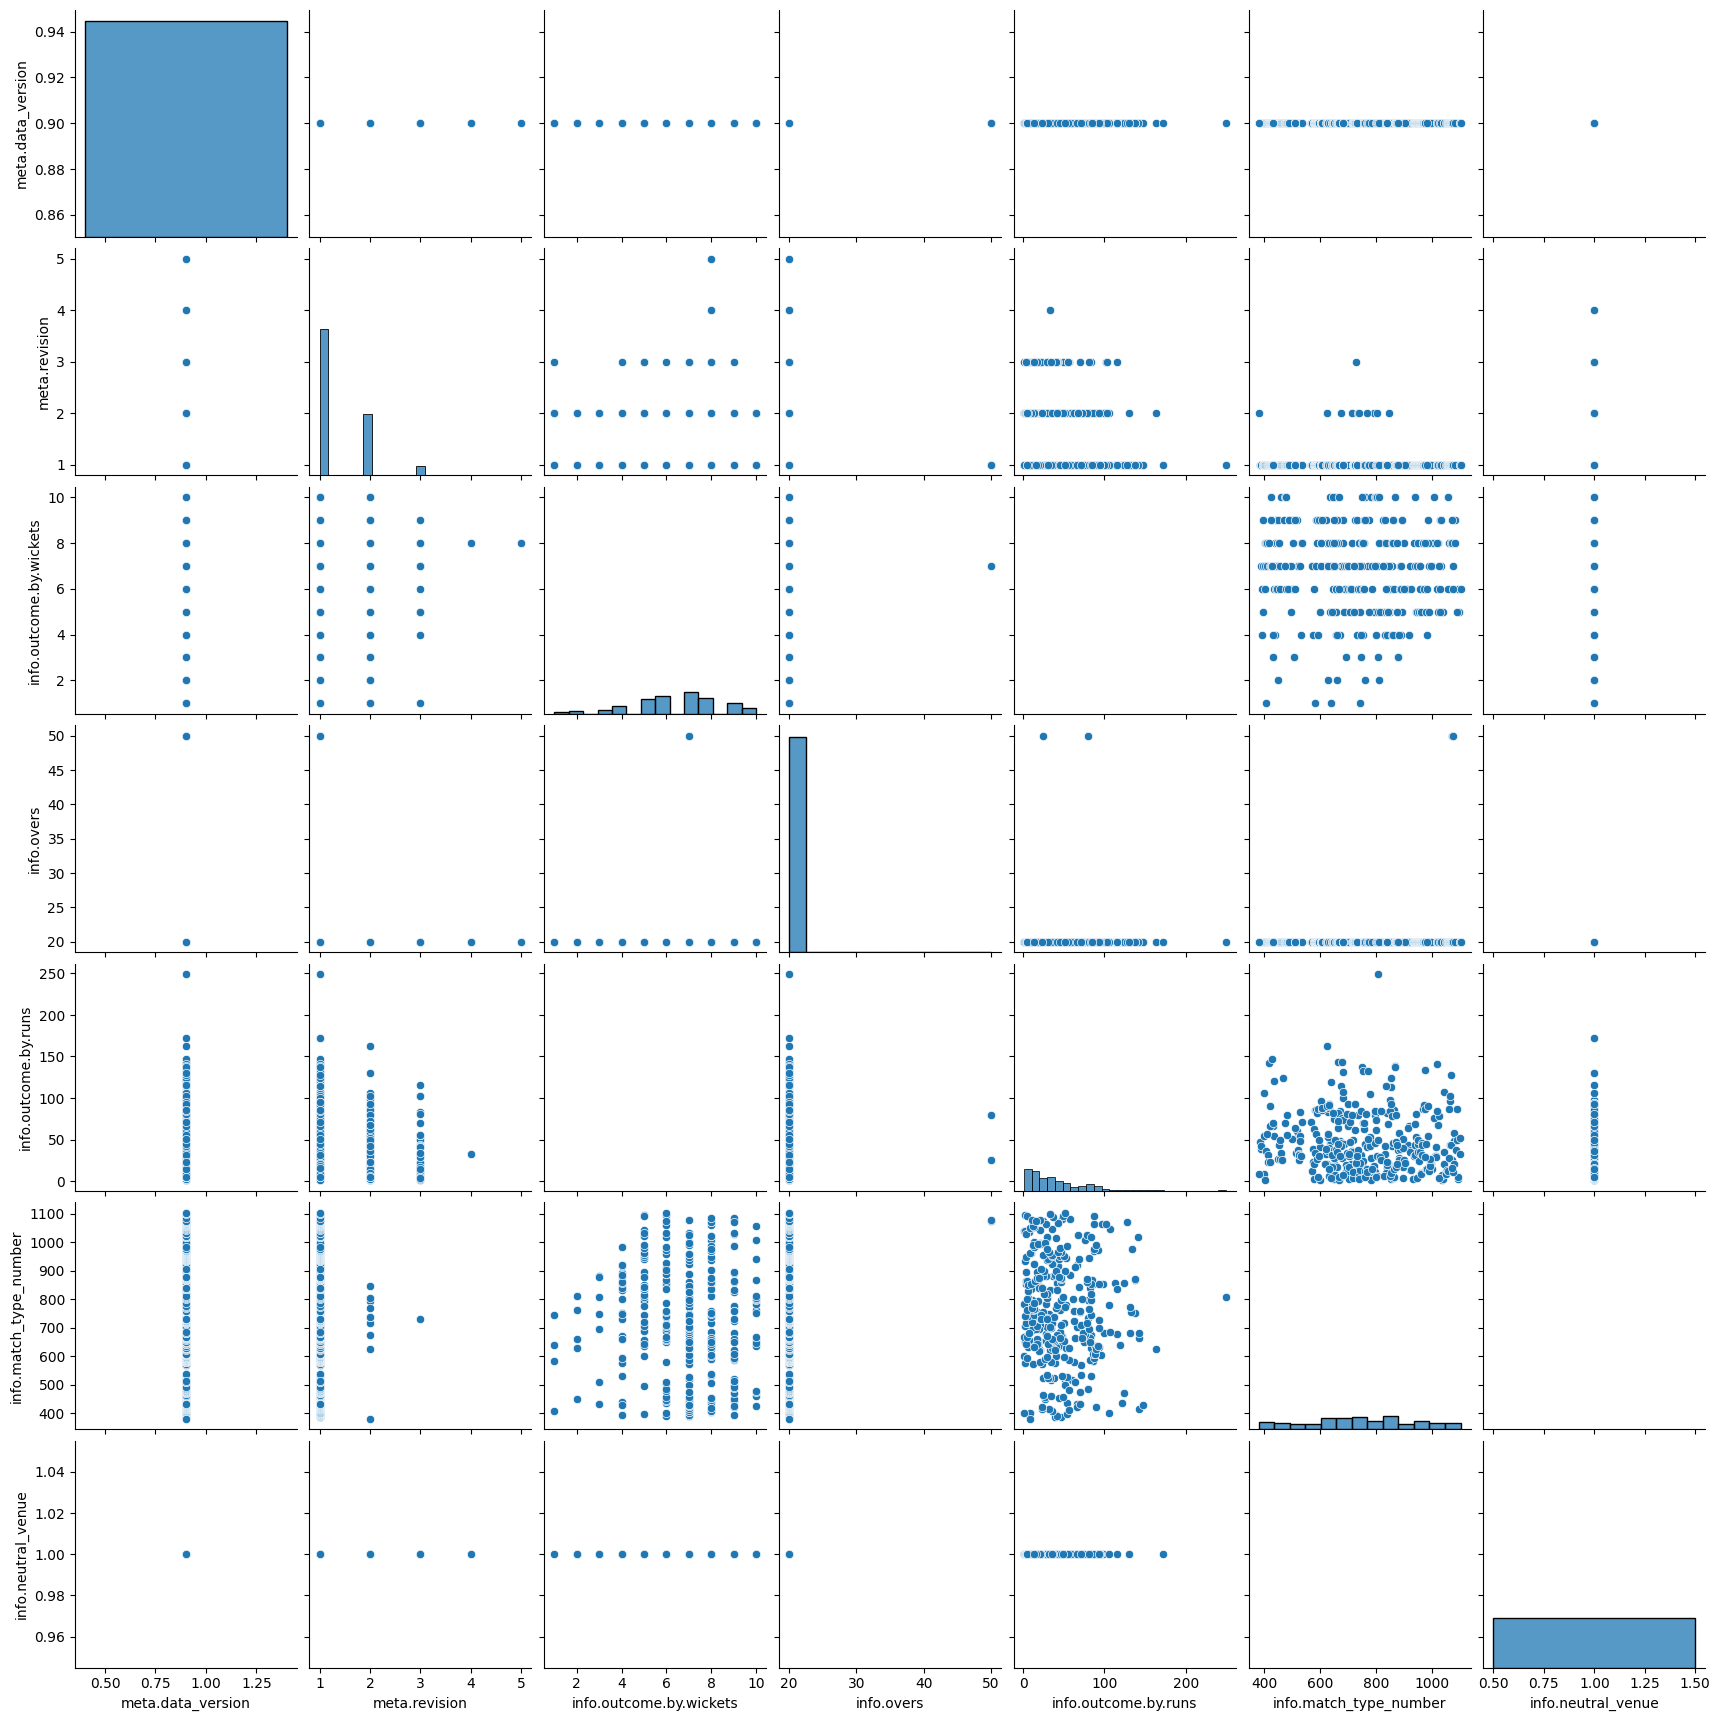

In [ ]:
sns.pairplot(df)
plt.show()


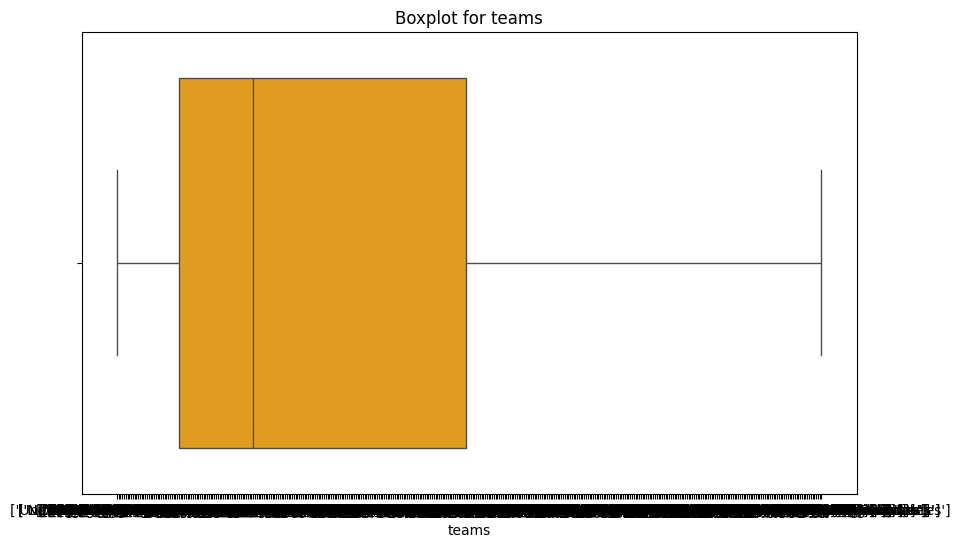

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['info.teams'], color='orange')
plt.title('Boxplot for teams')
plt.xlabel('teams')
plt.show()